## Introduction

The goal of this notebook is to **backtest a portfolio of option replication strategies on volatility target assets**.

## Librairies

In [297]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from typing import Dict
import plotly.express as px
from scipy.stats import norm
from python_module.pricing_model import BSMModel

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

pd.options.display.max_rows = 999
pd.options.display.max_columns = 999
pd.options.display.float_format = '{:,.4f}'.format

## Functions

In [298]:
def compute_vt_price(price_ts, exp_window, target_vol, init_vt_price = 100):
    price_df = price_ts.to_frame(name='risky_asset')
    log_returns_df = np.log(price_df).diff()
    rolling_std_df = log_returns_df.ewm(span=exp_window, min_periods=exp_window, adjust=False).std()
    rolling_std_df *= (252 ** 0.5)
    leverage_df = target_vol / rolling_std_df
    vt_price_df = (price_df.loc[leverage_df.dropna().index].pct_change() * leverage_df.shift(1)).fillna(0).add(1).cumprod() * init_vt_price
    vt_price_df.columns = ['F']
    agg_df = pd.concat([price_df, leverage_df['risky_asset'].to_frame('beta'), vt_price_df], axis=1).dropna()
    agg_df['vt_delta'] = (agg_df['F'] * agg_df['beta'])/agg_df['risky_asset']
    return agg_df

def apply_compute_option(row):
    inputs = row[['F', 'K', 'T', 'r', 'sigma', 'option_type', 'compute_greeks', 'slide_scenario', 'slide_compute']].to_dict()
    return BSMModel.compute_option(**inputs)

def compute_vt_option_bt(agg_df, day_to_maturity, strike_delta, target_vol, slide_scenario):
    
    results = list()
    for date in tqdm(agg_df.index):
        agg_df_temp = agg_df.loc[date:].iloc[:day_to_maturity+1]
        if agg_df_temp.shape[0] != day_to_maturity+1: break
        agg_df_temp['strike_date'] = agg_df_temp.index[0]
        agg_df_temp['maturity_date'] = agg_df_temp.index[-1]
        agg_df_temp['days_to_maturity'] = list(range(agg_df_temp.shape[0]))[::-1]
        agg_df_temp['T'] = agg_df_temp['days_to_maturity'] / 252

        option_type = 'call' if strike_delta > 0 else 'put'
        agg_df_temp['option_type'] = option_type

        strike_k = BSMModel.solve_delta_strike(F=100, T=day_to_maturity/252, sigma=target_vol, r=0, option_type=option_type, target_delta=strike_delta)
        strike_pct = strike_k / 100
        agg_df_temp['K'] = agg_df_temp['F'].iloc[0] * strike_pct
        agg_df_temp['r'] = 0
        agg_df_temp['sigma'] = target_vol
        agg_df_temp['compute_greeks'] = True
        agg_df_temp['slide_scenario'] = slide_scenario
        agg_df_temp['slide_compute'] = 'option_pnl'
        
        pricing_df = agg_df_temp.apply(lambda x: apply_compute_option(x), axis=1, result_type='expand')
        agg_df_temp = pd.concat([agg_df_temp, pricing_df], axis=1)
        agg_df_temp['asset_delta'] = agg_df_temp['vt_delta'] * agg_df_temp['delta']
        agg_df_temp['asset_delta_cash'] = agg_df_temp['risky_asset'] * agg_df_temp['asset_delta']
        agg_df_temp['dP'] = agg_df_temp['price'].diff()
        agg_df_temp['dH'] = agg_df_temp['risky_asset'].diff() * agg_df_temp['asset_delta'].shift(1)
        results.append(agg_df_temp)
    results_df = pd.concat(results)
    return results_df

def compute_scaling(trading_units, trading_scale, results_df, slide_scenario, day_to_maturity, cols=['asset_delta_cash','dP', 'dH']):
    scaling_factor = trading_units / results_df.groupby('strike_date')[trading_scale].first()
    results_df['scaling_factor'] = results_df['strike_date'].map(scaling_factor)
    for col in cols:
        results_df[f'scaled_{col}'] = results_df['scaling_factor'] * results_df[col]
    results_df[f'scaled_{trading_scale}'] = results_df['scaling_factor'] * results_df[trading_scale]
    results_df[f'scaled_{slide_scenario}'] = results_df['scaling_factor'] * results_df[slide_scenario]
    nb_strike = results_df.groupby(results_df.index)['strike_date'].count()
    mask = (nb_strike == (day_to_maturity+1))
    results_df = results_df.loc[mask]
    return results_df

def bsm_vectorized(
    F: np.ndarray, K: np.ndarray, T: np.ndarray, r: float, sigma: float, 
    option_type: str
) -> Dict[str, np.ndarray]:
    """
    Vectorized implementation of Black-76 to handle matrix inputs.
    """
    # Initialize output arrays
    prices = np.zeros_like(F)
    deltas = np.full_like(F, np.nan)
    gammas = np.full_like(F, np.nan)
    vegas = np.full_like(F, np.nan)
    thetas = np.full_like(F, np.nan)
    vannas = np.full_like(F, np.nan)
    volgas = np.full_like(F, np.nan)

    # Handle T=0 case separately (Expiry)
    mask_expiry = np.isclose(T, 0)
    mask_active = ~mask_expiry
    
    # --- Expiry Logic (T=0) ---
    if option_type == 'call':
        prices[mask_expiry] = np.maximum(F[mask_expiry] - K[mask_expiry], 0)
    else:
        prices[mask_expiry] = np.maximum(K[mask_expiry] - F[mask_expiry], 0)
    
    # --- Active Logic (T>0) ---
    if np.any(mask_active):
        F_act = F[mask_active]
        K_act = K[mask_active]
        T_act = T[mask_active]
        
        d1 = (np.log(F_act / K_act) + (0.5 * sigma ** 2) * T_act) / (sigma * np.sqrt(T_act))
        d2 = d1 - sigma * np.sqrt(T_act)
        discount = np.exp(-r * T_act)
        
        cdf_d1 = norm.cdf(d1)
        cdf_d2 = norm.cdf(d2)
        pdf_d1 = norm.pdf(d1)
        
        # Price
        if option_type == 'call':
            prices[mask_active] = discount * (F_act * cdf_d1 - K_act * cdf_d2)
            deltas[mask_active] = discount * cdf_d1
        else:
            prices[mask_active] = discount * (K_act * norm.cdf(-d2) - F_act * norm.cdf(-d1))
            deltas[mask_active] = discount * (cdf_d1 - 1)
            
        # Greeks
        gammas[mask_active] = discount * pdf_d1 / (F_act * sigma * np.sqrt(T_act))
        vegas[mask_active] = discount * F_act * pdf_d1 * np.sqrt(T_act) / 100
        thetas[mask_active] = (
            -F_act * pdf_d1 * sigma / (2 * np.sqrt(T_act)) * discount 
            + r * prices[mask_active]
        ) / 252
        vannas[mask_active] = -discount * ((d2 * pdf_d1) / sigma)
        volgas[mask_active] = vegas[mask_active] * 100 * (d1 * d2 / sigma)

    return {
        "price": prices, "delta": deltas, "gamma": gammas, 
        "vega": vegas, "theta": thetas, "vanna": vannas, "volga": volgas
    }

def compute_vt_option_bt_fast(agg_df, day_to_maturity, strike_delta, target_vol, slide_scenario):
    
    # 1. Pre-Calculation Setup
    # ------------------------
    # Optimization: Solve for strike percentage ONLY ONCE.
    # The original inputs (F=100, r=0, sigma=target_vol) are constant across the loop.
    option_type = 'call' if strike_delta > 0 else 'put'
    strike_k_nominal = BSMModel.solve_delta_strike(
        F=100, T=day_to_maturity/252, sigma=target_vol, r=0, 
        option_type=option_type, target_delta=strike_delta
    )
    strike_pct = strike_k_nominal / 100.0

    # Ensure slide_scenario is a list
    if not isinstance(slide_scenario, list):
        slide_scenario = [slide_scenario]

    # 2. Vectorized Window Construction
    # ---------------------------------
    # Instead of iterating, we build indices to select all windows at once.
    N = len(agg_df)
    window_len = day_to_maturity + 1
    
    # Identify valid start indices (where a full window exists)
    n_windows = N - day_to_maturity
    if n_windows <= 0:
        return pd.DataFrame() # Return empty if data too short
        
    starts = np.arange(n_windows)
    offsets = np.arange(window_len)
    
    # Create 2D index matrix (n_windows x window_len)
    # Row i contains indices [i, i+1, ..., i+window_len-1]
    idx_matrix = starts[:, None] + offsets[None, :]
    
    # Extract Data using Fancy Indexing (Broadcasting)
    # Shape of these matrices: (n_windows, window_len)
    F_matrix = agg_df['F'].values[idx_matrix]
    risky_asset_matrix = agg_df['risky_asset'].values[idx_matrix]
    vt_delta_matrix = agg_df['vt_delta'].values[idx_matrix]
    dates_matrix = agg_df.index.values[idx_matrix]
    
    # Construct Parameter Matrices
    # K is determined by F at the START of the window (column 0), broadcasted across columns
    K_vector = F_matrix[:, 0] * strike_pct 
    K_matrix = K_vector[:, None] * np.ones((1, window_len)) # Repeat for window columns
    
    # T is deterministic: [M, M-1, ..., 0] / 252
    T_vector = np.arange(window_len)[::-1] / 252.0
    T_matrix = np.tile(T_vector, (n_windows, 1))
    
    # 3. Vectorized BSM Computation
    # -----------------------------
    base_res = bsm_vectorized(F_matrix, K_matrix, T_matrix, r=0, sigma=target_vol, option_type=option_type)
    
    # 4. Slide Scenarios (PnL)
    # ------------------------
    slide_results = {}
    for slide in slide_scenario:
        if slide is None: continue
        F_bumped = F_matrix * (1 + slide)
        bumped_res = bsm_vectorized(F_bumped, K_matrix, T_matrix, r=0, sigma=target_vol, option_type=option_type)
        # slide_compute == 'option_pnl' logic:
        slide_results[slide] = bumped_res['price'] - base_res['price']

    # 5. Derived Computations (Delta, dP, dH)
    # ---------------------------------------
    asset_delta = vt_delta_matrix * base_res['delta']
    asset_delta_cash = risky_asset_matrix * asset_delta
    
    # dP: Change in option price within the window (along axis 1)
    # We prepend NaN to match shape
    dP = np.hstack([np.full((n_windows, 1), np.nan), np.diff(base_res['price'], axis=1)])
    
    # dH: Change in hedge
    # dH[t] = (RiskAsset[t] - RiskAsset[t-1]) * AssetDelta[t-1]
    diff_risky = np.diff(risky_asset_matrix, axis=1)
    lagged_delta = asset_delta[:, :-1] # Shift right effectively by taking 0..N-1
    dH_values = diff_risky * lagged_delta
    dH = np.hstack([np.full((n_windows, 1), np.nan), dH_values])

    # 6. Assembly (Flattening)
    # ------------------------
    # We flatten the matrices (ravel) to create the long-format DataFrame
    # Note: Flattening default is 'C' (row-major), which preserves the timeline within windows sequentially,
    # matching the original concatenation order.
    
    total_rows = n_windows * window_len
    
    data = {
        # Identifiers
        "strike_date": np.repeat(dates_matrix[:, 0], window_len), # Repeat start date
        "maturity_date": np.repeat(dates_matrix[:, -1], window_len), # Repeat end date
        "days_to_maturity": np.tile(np.arange(window_len)[::-1], n_windows),
        
        # Inputs (replicated for compatibility)
        "F": F_matrix.ravel(),
        "K": K_matrix.ravel(),
        "T": T_matrix.ravel(),
        "r": np.zeros(total_rows),
        "sigma": np.full(total_rows, target_vol),
        "option_type": [option_type] * total_rows, # List construction is fast enough
        "compute_greeks": [True] * total_rows,
        "slide_compute": ['option_pnl'] * total_rows,
        
        # Existing Data
        "risky_asset": risky_asset_matrix.ravel(),
        "vt_delta": vt_delta_matrix.ravel(),
        
        # Computed Results
        "price": base_res['price'].ravel(),
        "delta": base_res['delta'].ravel(),
        "gamma": base_res['gamma'].ravel(),
        "vega": base_res['vega'].ravel(),
        "theta": base_res['theta'].ravel(),
        "vanna": base_res['vanna'].ravel(),
        "volga": base_res['volga'].ravel(),
        
        # Computed Metrics
        "asset_delta": asset_delta.ravel(),
        "asset_delta_cash": asset_delta_cash.ravel(),
        "dP": dP.ravel(),
        "dH": dH.ravel()
    }
    
    # Add slide columns
    for slide, res_matrix in slide_results.items():
        data[slide] = res_matrix.ravel()
        # Add 'slide_scenario' column (can only hold one value per row in standard DF, 
        # original code put the *list* in the column, which is inefficient, but we replicate scalar/list behavior roughly)
        # To strictly match original schema where it puts the list object in every row:
        data['slide_scenario'] = [slide_scenario] * total_rows 

    # Create DataFrame
    results_df = pd.DataFrame(data, index=dates_matrix.ravel())
    
    return results_df

def compute_metrics(price_ts, title):

    dd = price_ts / price_ts.expanding().max() - 1
    max_dd = dd.min()
    print(f'max drawdown: {max_dd:.2%}')
    
    win_loss_ratio = price_ts.diff().clip(lower=0).sum() / -price_ts.diff().clip(upper=0).sum()
    print(f'win/loss ratio: {win_loss_ratio:.2f}')

    sharpe = (price_ts.pct_change().mean() * 252) / (price_ts.pct_change().std() * np.sqrt(252))
    print(f'sharpe ratio: {sharpe:.2f}')

    total_performance = price_ts.iloc[-1] / price_ts.iloc[0]
    n = ((price_ts.index[-1]-price_ts.index[0]).days / 365)
    x = total_performance**(1/n) -1
    print(f'annualized return: {x:.2%}')

    annual_returns = price_ts.groupby(price_ts.index.year).last().pct_change()

    multiplier = -0.55 / max_dd
    #multiplier = min([2, multiplier])
    print(f'multiplier: {multiplier:.2f}')
    annual_returns_scaled = annual_returns * multiplier
    x_scaled = annual_returns_scaled.add(1).prod()**(1/n) - 1
    print(f'annualized return scaled: {x_scaled:.2%}')

    plt.figure(figsize=(13, 4))
    sns.lineplot(data=price_ts)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(13, 4))
    sns.barplot(x=annual_returns.index.astype(str), y=annual_returns.values)
    plt.title(f'Annual Returns')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(13, 4))
    sns.barplot(x=annual_returns_scaled.index.astype(str), y=annual_returns_scaled.values)
    plt.title(f'Annual Returns Scaled')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    

## Inputs

In [299]:
# Components parameters
symbols = ['SPY']

# VT parameters
exp_window = 20
target_vol = 0.10

# Option parameters
strike_delta = -0.05
day_to_maturity = 250

# Risk & normalisation parameters
slide_scenario = -0.3
trading_scale = 'price'
trading_units = -300 / day_to_maturity

## Script

Average yearly return scaled: 8_899


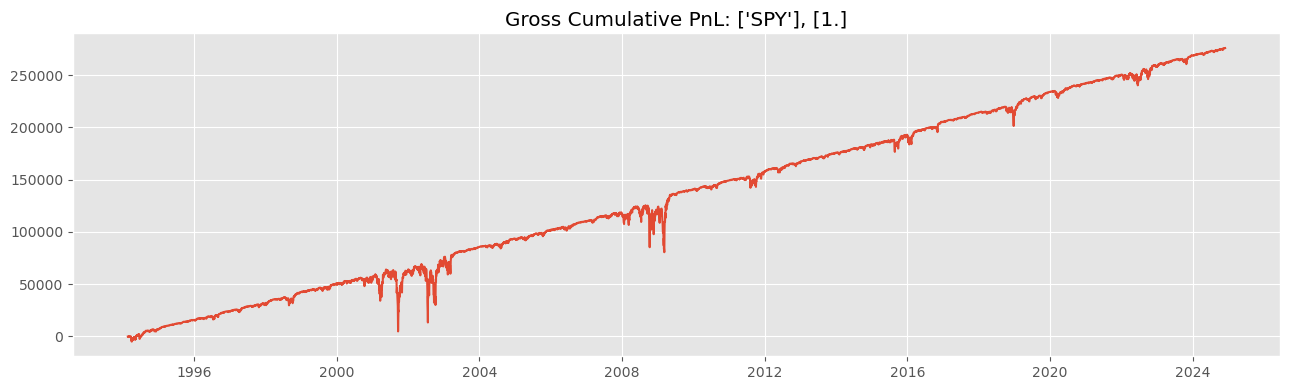

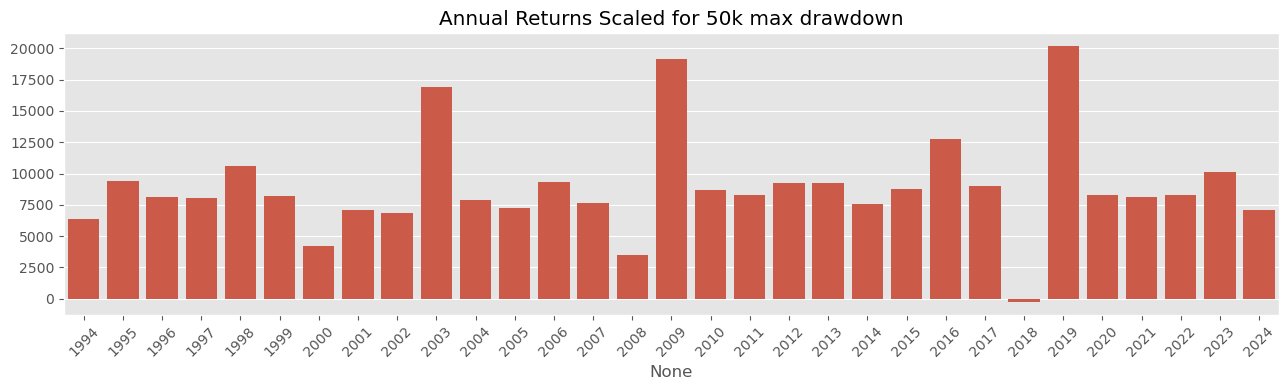

In [300]:
# Long symbol
gross_daily_pnl = dict()
for symbol in symbols:
    price_ts = pd.read_csv(f'data/{symbol}.csv', index_col=0, parse_dates=True)['price']
    agg_df = compute_vt_price(price_ts, exp_window, target_vol)
    results_df = compute_vt_option_bt_fast(agg_df, day_to_maturity, strike_delta, target_vol, slide_scenario)
    scaled_res_df = compute_scaling(trading_units, trading_scale, results_df, slide_scenario, day_to_maturity).copy()
    gross_daily_pnl[symbol] = scaled_res_df.groupby(scaled_res_df.index)['scaled_dH'].sum()
gross_daily_pnl_df = pd.DataFrame(gross_daily_pnl).dropna()

mu = gross_daily_pnl_df.mean()
sigma = gross_daily_pnl_df.cov()
inv_sigma = np.linalg.inv(sigma)
z = np.dot(inv_sigma, mu)
w_opt = z / np.sum(z)
gross_daily_pnl = gross_daily_pnl_df.dot(w_opt)
gross_anual_pnl = gross_daily_pnl.groupby(gross_daily_pnl.index.year).sum()
coeff = -50_000 / gross_daily_pnl.rolling(window=252).sum().min()
scaled_gross_anual_pnl = gross_anual_pnl * coeff
gross_level = gross_daily_pnl.cumsum() * coeff
print(f'Average yearly return scaled: {scaled_gross_anual_pnl.mean():_.0f}')

plt.figure(figsize=(13, 4))
sns.lineplot(data=gross_level)
plt.title(f'Gross Cumulative PnL: {symbols}, {w_opt}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 4))
sns.barplot(x=scaled_gross_anual_pnl.index.astype(str), y=scaled_gross_anual_pnl.values)
plt.title(f'Annual Returns Scaled for 50k max drawdown')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()